In [ ]:
all

Dataset shape: (2748, 276)
Columns: ['capacity_grav', 'fracA_charge', 'fracA_discharge', 'LCD', 'PLD', 'LCD_along_PLD', 'charge_formation_energy_per_atom', 'charge_volume', 'charge_density', 'charge_MagpieData minimum Number', 'charge_MagpieData maximum Number', 'charge_MagpieData range Number', 'charge_MagpieData mean Number', 'charge_MagpieData avg_dev Number', 'charge_MagpieData mode Number', 'charge_MagpieData minimum MendeleevNumber', 'charge_MagpieData maximum MendeleevNumber', 'charge_MagpieData range MendeleevNumber', 'charge_MagpieData mean MendeleevNumber', 'charge_MagpieData avg_dev MendeleevNumber', 'charge_MagpieData mode MendeleevNumber', 'charge_MagpieData minimum AtomicWeight', 'charge_MagpieData maximum AtomicWeight', 'charge_MagpieData range AtomicWeight', 'charge_MagpieData mean AtomicWeight', 'charge_MagpieData avg_dev AtomicWeight', 'charge_MagpieData mode AtomicWeight', 'charge_MagpieData minimum MeltingT', 'charge_MagpieData maximum MeltingT', 'charge_MagpieData 

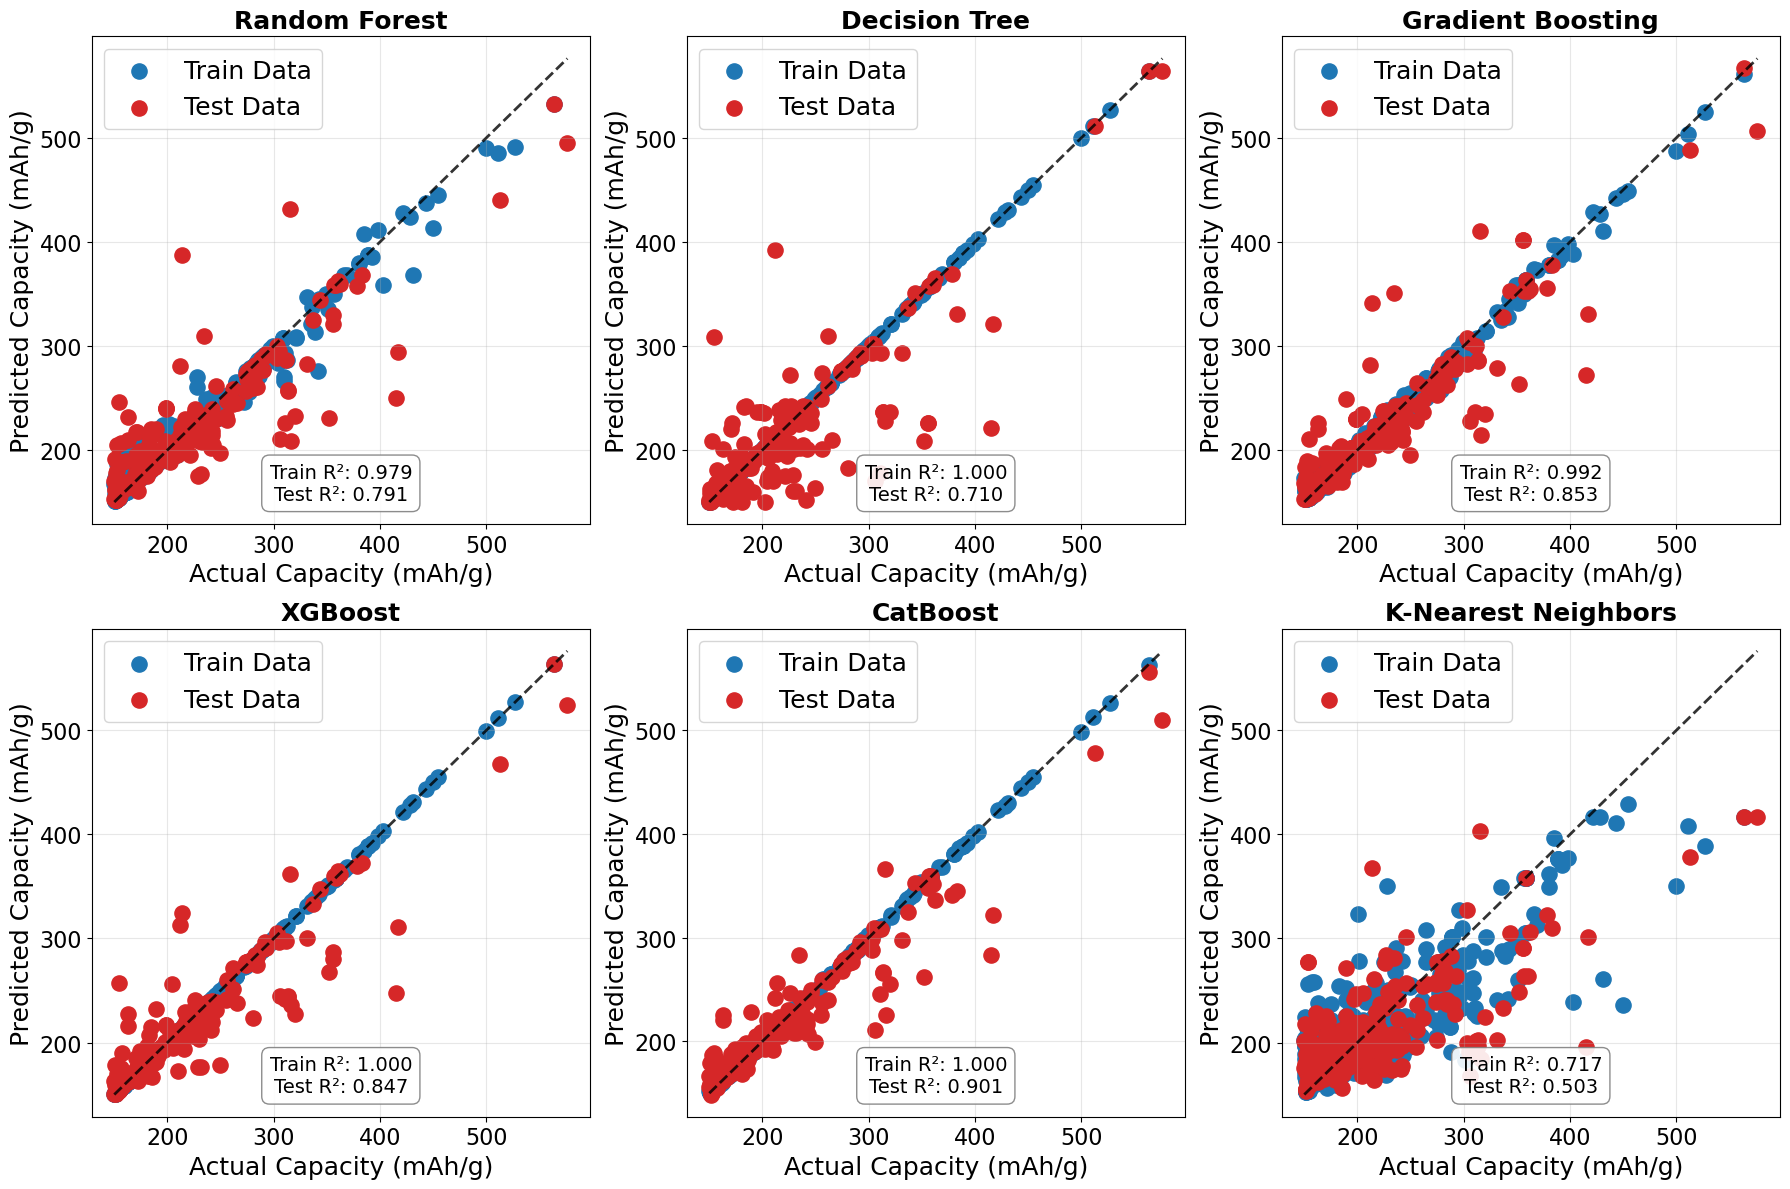


Summary of Results:
                     Train_MAE  Train_MSE  Train_R2  Test_MAE  Test_MSE  \
Random Forest            4.524     86.120     0.979    14.886   915.738   
Decision Tree            0.000      0.000     1.000    16.199  1269.580   
Gradient Boosting        4.155     34.447     0.992    12.977   645.158   
XGBoost                  0.022      0.001     1.000    11.746   670.601   
CatBoost                 0.860      1.309     1.000     9.991   433.574   
K-Nearest Neighbors     21.501   1147.990     0.717    30.736  2180.603   

                     Test_R2  
Random Forest          0.791  
Decision Tree          0.710  
Gradient Boosting      0.853  
XGBoost                0.847  
CatBoost               0.901  
K-Nearest Neighbors    0.503  
Top 10 Feature Importance Values:
 1. fracA_discharge          : 16.098330
 2. discharge_MagpieData mean NValence: 4.504296
 3. discharge_MagpieData mean Number: 4.173665
 4. discharge_MagpieData mean Column: 4.012917
 5. charge_MagpieD

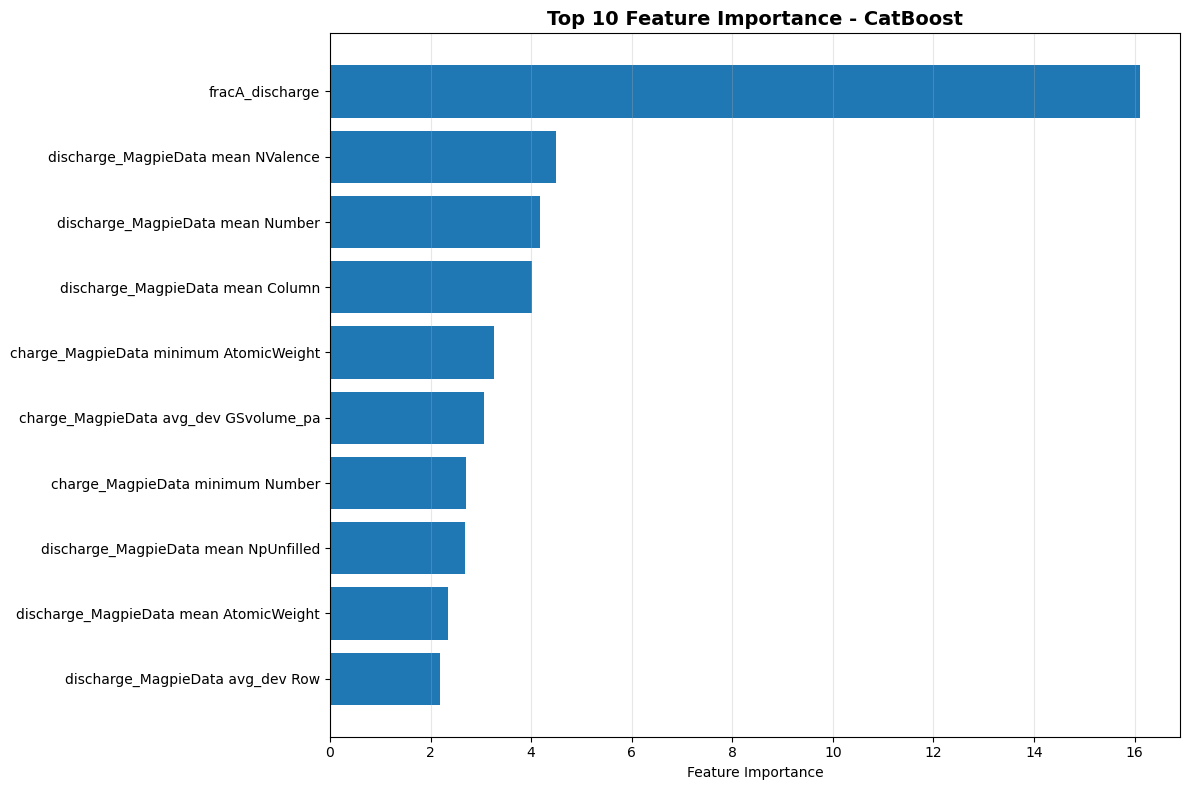


Normalization applied: StandardScaler
Features scaled: 253 features
Feature names: ['fracA_charge', 'fracA_discharge', 'LCD', 'PLD', 'LCD_along_PLD', 'charge_formation_energy_per_atom', 'charge_volume', 'charge_density', 'charge_MagpieData minimum Number', 'charge_MagpieData maximum Number', 'charge_MagpieData range Number', 'charge_MagpieData mean Number', 'charge_MagpieData avg_dev Number', 'charge_MagpieData mode Number', 'charge_MagpieData minimum MendeleevNumber', 'charge_MagpieData maximum MendeleevNumber', 'charge_MagpieData range MendeleevNumber', 'charge_MagpieData mean MendeleevNumber', 'charge_MagpieData avg_dev MendeleevNumber', 'charge_MagpieData mode MendeleevNumber', 'charge_MagpieData minimum AtomicWeight', 'charge_MagpieData maximum AtomicWeight', 'charge_MagpieData range AtomicWeight', 'charge_MagpieData mean AtomicWeight', 'charge_MagpieData avg_dev AtomicWeight', 'charge_MagpieData mode AtomicWeight', 'charge_MagpieData minimum MeltingT', 'charge_MagpieData maximum

In [7]:
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Read the filtered CSV file
df = pd.read_csv('all_electrodes_dataNaLi_with_MP_magpie.csv')

# Drop specified columns
columns_to_drop = ['charge_id_charge', 'charge_formula_pretty', 'discharge_id_discharge', 'discharge_formula_pretty']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Display basic info about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")

# Handle missing values in the target variable
df = df.dropna(subset=['capacity_grav'])

# Keep only rows with capacity_grav between 100 and 600
df = df[(df['capacity_grav'] >= 150) & (df['capacity_grav'] <= 600)]

# Display info after filtering
print(f"Dataset shape after filtering: {df.shape}")

# Designating X and y as variables for the features and capacity_grav respectively
X = df.drop(['capacity_grav'], axis=1)
y = df["capacity_grav"]

# Store original feature names before preprocessing
original_features = X.columns.tolist()

# Additional preprocessing: handle categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Handle remaining missing values
X = X.fillna(X.mean())

# Remove constant features
selector = VarianceThreshold()
X_selected = selector.fit_transform(X)

# Get the indices of selected features
selected_indices = selector.get_support(indices=True)
selected_feature_names = []

# Reconstruct feature names for the selected features
for idx in selected_indices:
    if idx < len(original_features):
        selected_feature_names.append(original_features[idx])
    else:
        # For one-hot encoded features, get the original column name
        # This is a simplified approach - you might need to adjust based on your actual column names
        selected_feature_names.append(f"Feature_{idx}")

# Convert back to DataFrame with proper feature names
X = pd.DataFrame(X_selected, columns=selected_feature_names)

# NORMALIZATION - Apply StandardScaler to features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Feature names: {list(X.columns)}")

# Models
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=None, min_samples_leaf=1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    mae_train = mean_absolute_error(y_train, yhat_train)
    mse_train = mean_squared_error(y_train, yhat_train)
    r2_train = r2_score(y_train, yhat_train)
    mae_test = mean_absolute_error(y_test, yhat_test)
    mse_test = mean_squared_error(y_test, yhat_test)
    r2_test = r2_score(y_test, yhat_test)
    results[name] = (mae_train, mse_train, r2_train, mae_test, mse_test, r2_test)
    print(f"Model: {name}")
    print(f"  Train MAE: {mae_train:.3f}, Train MSE: {mse_train:.3f}, Train R2: {r2_train:.3f}")
    print(f"  Test MAE: {mae_test:.3f}, Test MSE: {mse_test:.3f}, Test R2: {r2_test:.3f}")
    print("-" * 50)

# Set custom colors
train_color = '#1f77b4'  # Dark blue
test_color = '#d62728'   # Dark red

# Plot all models in one figure
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()

for i, (name, model) in enumerate(models.items()):
    if i >= len(axs):
        break
        
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    
    # Increased circle size (s=40) and custom colors
    axs[i].scatter(y_train, yhat_train, alpha=1, label='Train Data', s=120, color=train_color, linewidth=1)
    axs[i].scatter(y_test, yhat_test, alpha=1, label='Test Data', s=120, color=test_color, linewidth=1)
    
    # Plot perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.8)
    
    axs[i].set_xlabel('Actual Capacity (mAh/g)', fontsize=18)
    axs[i].set_ylabel('Predicted Capacity (mAh/g)', fontsize=18)
    axs[i].set_title(name, fontsize=18, fontweight='bold')
    axs[i].legend(fontsize=18)
    
    # Add grid for better readability
    axs[i].grid(True, alpha=0.3)
    
    # Add training and test accuracy
    mae_train, mse_train, r2_train, mae_test, mse_test, r2_test = results[name]
    axs[i].text(0.5, 0.05, f'Train R²: {r2_train:.3f}\nTest R²: {r2_test:.3f}', 
                ha='center', transform=axs[i].transAxes, fontsize=14,
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor='gray'))
    
    axs[i].tick_params(axis='both', which='major', labelsize=16)
    
# Remove any empty subplots
for i in range(len(models), len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.savefig('capacity_grav_prediction_models.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Create a summary dataframe of results
results_df = pd.DataFrame.from_dict(results, orient='index', 
                                   columns=['Train_MAE', 'Train_MSE', 'Train_R2', 
                                           'Test_MAE', 'Test_MSE', 'Test_R2'])
print("\nSummary of Results:")
print(results_df.round(3))

# Additional: Plot feature importance for the best model 
best_model_name = results_df['Test_R2'].idxmax()
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,  # Use the actual feature names
        'importance': best_model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False).head(10)
    
    # Print the top 10 feature importance values
    print("Top 10 Feature Importance Values:")
    print("=" * 50)
    for i, (idx, row) in enumerate(feature_importance.iterrows(), 1):
        print(f"{i:2d}. {row['feature']:25s}: {row['importance']:.6f}")
    print()
    
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color=train_color)
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('feature_importance1.png', dpi=300, bbox_inches='tight')
    plt.show()

# Print normalization info
print(f"\nNormalization applied: StandardScaler")
print(f"Features scaled: {X.shape[1]} features")
print(f"Feature names: {list(X.columns)}")
print(f"Feature means after scaling: {X.mean().mean():.3f}")
print(f"Feature std after scaling: {X.std().mean():.3f}")

In [6]:
# Load the prediction dataset
prediction_df = pd.read_csv('all_prediction_MP_magpie.csv')

# Store the original prediction dataframe for later
original_prediction_df = prediction_df.copy()

# Display basic info about the prediction dataset
print(f"Prediction dataset shape: {prediction_df.shape}")
print(f"Prediction columns: {list(prediction_df.columns)}")

# Apply the same preprocessing steps as training data
# Drop the same columns if they exist
columns_to_drop = ['charge_id_charge', 'charge_formula_charge', 'discharge_id_discharge', 'discharge_formula_discharge']
prediction_df = prediction_df.drop(columns=columns_to_drop, errors='ignore')

# Handle categorical columns (same as training)
categorical_cols = prediction_df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    prediction_df = pd.get_dummies(prediction_df, columns=categorical_cols, drop_first=True)

# Ensure the prediction data has the same columns as training data
# Add missing columns with 0 values
missing_cols = set(X.columns) - set(prediction_df.columns)
for col in missing_cols:
    prediction_df[col] = 0

# Remove extra columns that weren't in training data
extra_cols = set(prediction_df.columns) - set(X.columns)
prediction_df = prediction_df.drop(columns=extra_cols)

# Reorder columns to match training data exactly
prediction_df = prediction_df[X.columns]

# Handle missing values (same as training)
prediction_df = prediction_df.fillna(X.mean())  # Use training data mean

# Apply the same scaler used for training data
X_prediction_scaled = scaler.transform(prediction_df)
X_prediction = pd.DataFrame(X_prediction_scaled, columns=prediction_df.columns)

print(f"Processed prediction data shape: {X_prediction.shape}")
print(f"Features match training: {all(X_prediction.columns == X.columns)}")

# Make predictions using the CatBoost model
catboost_model = models['CatBoost']
predictions = catboost_model.predict(X_prediction)

print(f"Number of predictions made: {len(predictions)}")
print(f"Prediction range: {predictions.min():.2f} to {predictions.max():.2f} mAh/g")

# Create a results dataframe with pretty formatting
results_df = pd.DataFrame({
    'Formula': original_prediction_df.get('formula', original_prediction_df.iloc[:, 0]),  # Use formula column or first column
    'Predicted_Capacity_mAh_g': predictions,
    'Predicted_Capacity_Rounded': np.round(predictions, 2)
})

# Add additional formatted columns for better readability
results_df['Capacity_Formatted'] = results_df['Predicted_Capacity_Rounded'].apply(lambda x: f"{x:.2f} mAh/g")
results_df['Capacity_Category'] = pd.cut(predictions, 
                                       bins=[0, 100, 200, 300, 400, 500, float('inf')],
                                       labels=['0-100', '100-200', '200-300', '300-400', '400-500', '500+'])

# Display some sample predictions
print("\nSample predictions:")
print("=" * 60)
print(results_df.head(10).to_string(index=False))

# Save predictions to CSV with pretty formatting
output_filename = 'catboost_predictions_formatted.csv'
results_df.to_csv(output_filename, index=False)

# Also save a simplified version with just the essential columns
simplified_df = results_df[['Formula', 'Predicted_Capacity_mAh_g', 'Capacity_Formatted']]
simplified_df.columns = ['Material_Formula', 'Predicted_Capacity', 'Formatted_Capacity']
simplified_df.to_csv('catboost_predictions_simple.csv', index=False)

print(f"\nPredictions saved to:")
print(f"- {output_filename} (full formatted version)")
print(f"- catboost_predictions_simple.csv (simplified version)")
print(f"Total materials predicted: {len(predictions)}")
print(f"Average predicted capacity: {np.mean(predictions):.2f} ± {np.std(predictions):.2f} mAh/g")

Prediction dataset shape: (3, 279)
Prediction columns: ['charge_id_charge', 'charge_formula_pretty', 'fracA_charge', 'fracA_discharge', 'LCD', 'PLD', 'LCD_along_PLD', 'charge_formation_energy_per_atom', 'charge_volume', 'charge_density', 'charge_MagpieData minimum Number', 'charge_MagpieData maximum Number', 'charge_MagpieData range Number', 'charge_MagpieData mean Number', 'charge_MagpieData avg_dev Number', 'charge_MagpieData mode Number', 'charge_MagpieData minimum MendeleevNumber', 'charge_MagpieData maximum MendeleevNumber', 'charge_MagpieData range MendeleevNumber', 'charge_MagpieData mean MendeleevNumber', 'charge_MagpieData avg_dev MendeleevNumber', 'charge_MagpieData mode MendeleevNumber', 'charge_MagpieData minimum AtomicWeight', 'charge_MagpieData maximum AtomicWeight', 'charge_MagpieData range AtomicWeight', 'charge_MagpieData mean AtomicWeight', 'charge_MagpieData avg_dev AtomicWeight', 'charge_MagpieData mode AtomicWeight', 'charge_MagpieData minimum MeltingT', 'charge_Ma

In [9]:
# Save all CatBoost data in one file with train_actual, train_predicted, test_actual, test_predicted
catboost_model = models['CatBoost']

# Get predictions
yhat_train_catboost = catboost_model.predict(X_train)
yhat_test_catboost = catboost_model.predict(X_test)

# Create a combined DataFrame with all predictions
# Determine the maximum length to handle different sizes
max_length = max(len(y_train), len(y_test))

# Create the combined DataFrame with proper alignment
catboost_data = pd.DataFrame({
    'train_actual': pd.Series(y_train.values, index=range(len(y_train))).reindex(range(max_length)),
    'train_predicted': pd.Series(yhat_train_catboost, index=range(len(yhat_train_catboost))).reindex(range(max_length)),
    'test_actual': pd.Series(y_test.values, index=range(len(y_test))).reindex(range(max_length)),
    'test_predicted': pd.Series(yhat_test_catboost, index=range(len(yhat_test_catboost))).reindex(range(max_length))
})

# Save to CSV file
catboost_data.to_csv('catboost_data.csv', index=False)

print("CatBoost data saved successfully to 'catboost_data.csv'!")
print(f"File shape: {catboost_data.shape}")
print(f"Train samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")

# Display first few rows
print("\nFirst 10 rows of the combined data:")
print(catboost_data.head(10))

# Display summary statistics
print("\nSummary statistics:")
print(catboost_data.describe())

CatBoost data saved successfully to 'catboost_data.csv'!
File shape: (604, 4)
Train samples: 604
Test samples: 260

First 10 rows of the combined data:
   train_actual  train_predicted  test_actual  test_predicted
0    350.772944       350.713050   165.635403      165.396509
1    204.820339       204.530580   161.423782      170.655452
2    228.616473       230.738523   152.459363      187.009873
3    288.506888       286.899448   217.779416      205.503058
4    241.817360       243.229278   166.499748      166.004031
5    227.614169       228.078028   210.078906      207.616833
6    265.007202       263.563790   261.388179      240.264705
7    198.795867       196.946555   360.384335      351.942224
8    225.347134       228.855509   576.239624      509.962788
9    189.203175       188.873688   208.671659      194.700484

Summary statistics:
       train_actual  train_predicted  test_actual  test_predicted
count    604.000000       604.000000   260.000000      260.000000
mean     210.